In [14]:
import matplotlib.pyplot as plt
import uproot4 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import scipy.optimize
from scipy.optimize import curve_fit
import random
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [15]:

# The POT defines "how much beam" we got, it is what is need to normalize data and MC.
data_pot = 2.513e+20

# EXT is cosmic induced events with no neutrino in the detector. This is "real data", but makes up part of our MC prediction (confusing!)
# We take data without the beam to estimate this.
# The "POT" of the EXT is defined by rescaling the number of triggered events in the EXT sample to the Data sample
ext_pot = data_pot*15769216.925000/5425918.0

# In the future, I can teach you how to obtain these for any sample, but just use these as is for now.

def gaus(x,a,x0,sigma, offset):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) + offset

#helper function to get bin centers
def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

#function to calculate the angle wrt the beam
def get_angle(momentum_0, momentum_1, momentum_2, to_numi=False):
    momentum_perp = np.sqrt(momentum_0 * momentum_0 + momentum_1 * momentum_1)
    # defined in https://root.cern/doc/master/TVector3_8cxx_source.html
    theta = np.arctan2(momentum_perp, momentum_2)
    phi = np.arctan2(momentum_0, momentum_1)
    
    if to_numi:
        # Apply coordinate transformation to NuMI beam frame
        # This is a placeholder - you'll need the actual transformation
        # Typically involves rotating the coordinate system
        pass
    
    return theta, phi


In [16]:
eval_vars = ["match_isFC","run","subrun","event", "stm_eventtype", "stm_lowenergy", "stm_clusterlength"]
eval_mc_vars = ["weight_spline","weight_cv"]

pf_eval_vars = ["reco_muonMomentum", "reco_showerMomentum", "reco_Ntrack", "reco_protonMomentum", "reco_startMomentum", "reco_endMomentum", "reco_startXYZT", "reco_endXYZT", "reco_mother", "reco_pdg", "reco_id", "evtTimeNS"]
pf_eval_mc_vars = ["truth_isCC","truth_nuPdg", "evtTimeNS_cor"]

bdt_vars = [
    "mip_energy",
    "mip_angle_beam", 
    "spt_angle_vertical",
    "nue_score", 
    "numu_score", 
    "numu_cc_flag",
    "numu_1_score",
    "numu_cc_3_track_length",
    "numu_cc_3_max_length_all",
    "cosmict_2_dQ_dx_front",
    "cosmict_2_dQ_dx_end",
    "cosmict_2_angle_beam",
    "cosmict_2_phi",
    "numu_cc_3_max_length",
    "numu_cc_3_max_muon_length",

    "numu_cc_flag_1",
    "numu_cc_flag_2",
    "numu_cc_flag_3",
    "cosmict_flag",
    
    "numu_cc_1_length",
    "numu_cc_1_direct_length",
    "numu_cc_2_length",
    "numu_cc_2_total_length",
]

kine_vars_data = ["kine_particle_type", "kine_energy_particle", "kine_reco_add_energy", "kine_energy_info",
                 "kine_pio_mass",
                    "kine_pio_flag",
                    "kine_pio_vtx_dis",
                    "kine_pio_energy_1",
                    "kine_pio_theta_1",
                    "kine_pio_phi_1",
                    "kine_pio_dis_1",
                    "kine_pio_energy_2",
                    "kine_pio_theta_2",
                    "kine_pio_phi_2",
                    "kine_pio_dis_2",
                    "kine_pio_angle"]
kine_vars = ["kine_reco_Enu", "kine_pio_flag", "kine_pio_vtx_dis", "kine_pio_energy_1", "kine_pio_energy_2","kine_pio_theta_1", "kine_pio_theta_2", "kine_pio_phi_1", "kine_pio_phi_2", "kine_pio_angle","kine_pio_dis_1", "kine_pio_mass", "kine_energy_info", "kine_energy_particle", "kine_particle_type", "kine_reco_add_energy"]

In [17]:
import sys, os
print("sys.executable:", sys.executable)
print("platform:", sys.platform)
print("KRB5CCNAME:", os.environ.get("KRB5CCNAME"))

sys.executable: /opt/conda/bin/python
platform: linux
KRB5CCNAME: None


In [18]:
file_name = "../newbdt/checkout_MCC9.10_Run4b_v10_04_07_20_NuMI_beam_on_retuple_retuple_hist_opendata_20400_20600.root"

f_ext = uproot.open(file_name)["wcpselection"]

f_ext_bdt = f_ext["T_BDTvars"].arrays(bdt_vars, library='pd')
f_ext_eval = f_ext["T_eval"].arrays(eval_vars, library='pd')
f_ext_pfeval = f_ext["T_PFeval"].arrays(pf_eval_vars, library='pd')
f_ext_kine = f_ext["T_KINEvars"].arrays(library='pd')
# Below is the new part!
f_ext_pot = f_ext["T_pot"].arrays("pot_tor875good", library='pd')
ext_POT = np.sum(f_ext_pot["pot_tor875good"].to_numpy()) 
# Above is the new part!
overlay_df = pd.concat([f_ext_bdt, f_ext_eval, f_ext_pfeval, f_ext_kine], axis=1, sort=False)

del f_ext
del f_ext_bdt
del f_ext_eval
del f_ext_pfeval
del f_ext_kine
del f_ext_pot

print("All events",overlay_df.shape[0])
# Good practice to check for duplicates
overlay_df["rse_num"] = (overlay_df["run"].astype(int) * 100_000_000_000
                         + overlay_df["subrun"].astype(int) * 1_000_000
                         + overlay_df["event"].astype(int))
overlay_df = overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",overlay_df.shape[0])


# This defines the POT scaling of this MC sample to the data
overlay_df["POTscaled"] = [data_pot/ext_pot for i in range(overlay_df.shape[0])]
# NOTE: when you start including multiple runs (4a,4b,...), the POT scaling need to be calculated seperate for each!

# EXT does not have event weights, so just need to do the POT scaling
overlay_df["net_weight_POTscaled"] = overlay_df["POTscaled"].to_numpy()

FileNotFoundError: [Errno 2] No such file or directory: '/home/achan/../newbdt/checkout_MCC9.10_Run4b_v10_04_07_20_NuMI_beam_on_retuple_retuple_hist_opendata_20400_20600.root'

In [ ]:
#merge everything into a single peak
#you may have to play around with Shift to get things aligned at 0
numi_gap = 18.831
evtTimeNS = overlay_df["evtTimeNS"].to_numpy()

new_times = []

for i in range(len(evtTimeNS)):
    
    if np.nan_to_num(evtTimeNS[i],nan=-999999,posinf=-999999,neginf=-999999)<=0:
        new_times.append(-9999)
        continue  
        
    gap=numi_gap
    Shift=1.0718-0.0348
    TThelp=0

    TThelp = evtTimeNS[i]-Shift+gap*0.5

    TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        
    new_times.append(TT_merged)

overlay_df["merge_time"] = new_times

In [19]:
#Definitions for some slections and signals that are usefull to examine

em_charge_scale = 0.95

#numucc signal
sig_query = "truth_isCC==1 and truth_nuPdg==14"
#numucc selection
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
# "NC" selection. mostly just the base for the cut based NCpi0 selection
NC_query = "cosmict_flag==0 and numu_score < 0"
#CC pi0 cut based selection
CCpi0_query = sel_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1* @em_charge_scale > 40 and kine_pio_energy_2* @em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 BDT based selection
NCpi0_bdt_query = 'nc_pio_score > 1.816 and kine_pio_energy_1 > 0 and kine_pio_energy_2 > 0'

In [20]:
def plot_time_distribution(df, time_col = "merge_time", label=""):
    nbins = 12

    # Helper for query string
    time_query = f"{time_col}>-9.42 and {time_col}<9.42"

    data_numuCC = df.query(time_query).query("numu_score>0.9")[time_col].to_numpy()
    norm1 = len(data_numuCC)
    y, xbins = np.histogram(data_numuCC, bins=nbins, range=(-9.42, 9.42))
    x1 = get_bin_centers(xbins)
    popt, pcov = curve_fit(gaus, x1, y / norm1)
    print("numuCC: Gaussian      mean:", round(popt[1], 4), "  std:", round(popt[2], 4), "  C:", round(popt[3], 4))

    data_CCpi0 = df.query(time_query).query(CCpi0_query)[time_col].to_numpy()
    norm2 = len(data_CCpi0)
    y2, xbins = np.histogram(data_CCpi0, bins=nbins, range=(-9.42, 9.42))
    x2 = get_bin_centers(xbins)
    popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
    print("CCpi0: Gaussian      mean:", round(popt2[1], 4), "  std:", round(popt2[2], 4), "  C:", round(popt2[3], 4))

    data_NCpi0 = df.query(time_query).query(NCpi0_query)[time_col].to_numpy()
    norm3 = len(data_NCpi0)
    y3, xbins = np.histogram(data_NCpi0, bins=nbins, range=(-9.42, 9.42))
    x3 = get_bin_centers(xbins)
    popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)
    print("NCpi0: Gaussian      mean:", round(popt3[1], 4), "  std:", round(popt3[2], 4), "  C:", round(popt3[3], 4))

    data_nueCC = df.query(time_query).query("nue_score>4")[time_col].to_numpy()
    norm4 = len(data_nueCC)
    y4, xbins = np.histogram(data_nueCC, bins=nbins, range=(-9.42, 9.42))
    x4 = get_bin_centers(xbins)
    popt4, pcov4 = curve_fit(gaus, x4, y4 / norm4)
    print("loose nueCC: Gaussian      mean:", round(popt4[1], 4), "  std:", round(popt4[2], 4), "  C:", round(popt4[3], 4))

    if(time_col == "merge_time_linear_sps"):
        label = label + " (spacepoints)"
    else:
        label = label + " (Reco linear)"

    plt.figure()
    plt.title(label)
    plt.errorbar(x1, y / norm1, yerr=np.sqrt(y) / norm1, ms=8, lw=1, fmt='o', ecolor='darkorange', color='darkorange', capsize=3, capthick=2)
    plt.plot(x1, gaus(x1, *popt), color='orange', label='numuCC:' + '\n' + f"$\mu$={round(popt[1],2)}, $\\sigma$={round(abs(popt[2]),2)}")

    plt.errorbar(x2, y2 / norm2, yerr=np.sqrt(y2) / norm2, ms=8, lw=1, fmt='<', ecolor='darkgreen', color='darkgreen', capsize=3, capthick=2)
    plt.plot(x2, gaus(x2, *popt2), color='green', label='CCpi0:' + '\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")

    plt.errorbar(x3, y3 / norm3, yerr=np.sqrt(y3) / norm3, ms=8, lw=1, fmt='>', ecolor='blue', color='blue', capsize=3, capthick=2)
    plt.plot(x3, gaus(x3, *popt3), color='dodgerblue', label='NCpi0:' + '\n' + f"$\mu$={round(popt3[1],2)}, $\\sigma$={round(abs(popt3[2]),2)}")


    plt.errorbar(x4,y4/norm4,yerr=np.sqrt(y4)/norm4,ms=8, lw=1,fmt='>',ecolor = 'magenta',color='magenta', capsize=3, capthick=2)
    plt.plot(x4,gaus(x4,*popt4),color='magenta',label='loose nueCC:'+'\n'+f"$\mu$={round(popt4[1],2)}, $\\sigma$={round(abs(popt4[2]),2)}")

    '''shift_text = f"Shifts:\nCCpi0 = {shift_ccpi0}\nNCpi0 = {shift_ncpi0}\nNue = {shift_nue}"
    plt.gcf().text(1.1, 0.2, shift_text, fontsize=12, va='center', ha='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    '''

    plt.legend()
    plt.show()

plot_time_distribution(overlay_df, time_col="merge_time", label="df_numi_mc")


NameError: name 'overlay_df' is not defined

In [ ]:
stop

NameError: name 'pri' is not defined

In [ ]:
'''overlay_df.to_pickle("numi_4b_open_data_unprocessed")'''

In [21]:
overlay_df = pd.read_pickle("numi_4b_open_data_unprocessed")

FileNotFoundError: [Errno 2] No such file or directory: 'numi_4b_open_data_unprocessed'

In [ ]:
def scaling_recalc(data_run4b_super_df):
    
    em_charge_scale = 0.95
    data_run4b_super_df["pio_mass"] = data_run4b_super_df['kine_pio_mass'].to_numpy()* em_charge_scale
    data_run4b_super_df["em_charge_scale"] = np.ones_like(data_run4b_super_df['kine_pio_mass'].to_numpy())* em_charge_scale
    
    #Get the reconstructed neutrino energy, for data we need to apply a scaling to the shower energy
    corrected_kine_reco_Enus = []
    energy_info_lists = data_run4b_super_df["kine_energy_info"].to_numpy()
    energy_lists = data_run4b_super_df["kine_energy_particle"].to_numpy()
    pdg_lists = data_run4b_super_df["kine_particle_type"].to_numpy()
    add_energies = data_run4b_super_df["kine_reco_add_energy"].to_numpy()
    for i in tqdm(range(data_run4b_super_df.shape[0])):
        corrected_kine_reco_Enu = 0.
        energy_list = energy_lists[i]
        pdg_list = pdg_lists[i]
        energy_info_list = energy_info_lists[i]
        for j in range(len(energy_list)):
            if energy_info_list[j] == 2 and pdg_list[j] == 11:
                corrected_kine_reco_Enu += em_charge_scale * energy_list[j]
            else:
                corrected_kine_reco_Enu += energy_list[j]
        corrected_kine_reco_Enu += add_energies[i]
        
        corrected_kine_reco_Enus.append(corrected_kine_reco_Enu) 

    data_run4b_super_df["kine_reco_Enu"] = corrected_kine_reco_Enus

    

    #get the muon and leading proton info out of the pfeval tree
    mu = data_run4b_super_df["reco_muonMomentum"].to_numpy()
    
    '''mu0 = data_run4b_super_df["reco_muonMomentum[0]"].to_numpy()
    mu1 = data_run4b_super_df["reco_muonMomentum[1]"].to_numpy()
    mu2 = data_run4b_super_df["reco_muonMomentum[2]"].to_numpy()
    mu3 = data_run4b_super_df["reco_muonMomentum[3]"].to_numpy()

    p0 = data_run4b_super_df["reco_protonMomentum[0]"].to_numpy()
    p1 = data_run4b_super_df["reco_protonMomentum[1]"].to_numpy()
    p2 = data_run4b_super_df["reco_protonMomentum[2]"].to_numpy()
    p3 = data_run4b_super_df["reco_protonMomentum[3]"].to_numpy()'''

    
    p = data_run4b_super_df["reco_protonMomentum"].to_numpy()

    kine_reco_Enu = data_run4b_super_df["kine_reco_Enu"].to_numpy()

    mu_thetas = []
    mu_phis = []
    mu_costhetas = []
    mu_cosphis = []
    reco_Emuon = []

    p_thetas = []
    p_phis = []
    p_costhetas = []
    p_cosphis = []
    reco_Eproton = []

    Ehadron = []

    print(len(mu))

    for i in range(len(mu)):
        if(mu[i][3]<=0): 
            mu_theta = np.nan
            mu_phi = np.nan
            Ehadron.append(kine_reco_Enu[i])
        else: 
            mu_theta, mu_phi = get_angle(mu[i][0], mu[i][1], mu[i][2])
            Ehadron.append(kine_reco_Enu[i]-mu[i][3]*1000)
        mu_thetas.append(mu_theta)
        mu_phis.append(mu_phi)
        mu_costhetas.append(np.cos(mu_theta))
        mu_cosphis.append(np.cos(mu_phi))
        reco_Emuon.append(mu[i][3]*1000)
        
        if(p[i][3]<=0): 
            p_theta = np.nan
            p_phi = np.nan
            reco_Eproton.append(0)
            
        else: 
            p_theta, p_phi = get_angle(p[i][0], p[i][1], p[i][2])
            reco_Eproton.append(p[i][3]*1000-938.27)
        p_thetas.append(p_theta)
        p_phis.append(p_phi)
        p_costhetas.append(np.cos(p_theta))
        p_cosphis.append(np.cos(p_phi))
        
        
        
        
    print(len(data_run4b_super_df))
    print(len(mu_thetas), len(mu_phis), len(mu_costhetas), len(reco_Emuon))

    data_run4b_super_df["reco_muon_theta"] = mu_thetas
    data_run4b_super_df["reco_muon_phi"] = mu_phis
    data_run4b_super_df["reco_muon_costheta"] = mu_costhetas
    data_run4b_super_df["reco_muon_cosphi"] = mu_cosphis 
    data_run4b_super_df["reco_Emuon"] = reco_Emuon

    data_run4b_super_df["reco_proton_theta"] = p_thetas
    data_run4b_super_df["reco_proton_phi"] = p_phis
    data_run4b_super_df["reco_proton_costheta"] = p_costhetas
    data_run4b_super_df["reco_proton_cosphi"] = p_cosphis 
    data_run4b_super_df["reco_Eproton"] = reco_Eproton

    data_run4b_super_df["Ehadron"] = Ehadron

scaling_recalc(overlay_df)

100%|██████████| 143481/143481 [00:00<00:00, 1765682.70it/s]


143481
143481
143481 143481 143481 143481


In [ ]:
def track_saving(df_numi_mc):
    #add saving track pdgs
    reco_muonMoms0 = df_numi_mc["reco_muonMomentum"].iloc[0].to_numpy()
    reco_muonMoms1 = df_numi_mc["reco_muonMomentum"].iloc[1].to_numpy()
    reco_muonMoms2 = df_numi_mc["reco_muonMomentum"].iloc[2].to_numpy()
    reco_muonMoms3 = df_numi_mc["reco_muonMomentum"].iloc[3].to_numpy()

    reco_hadMoms0 = []
    reco_hadMoms1 = []
    reco_hadMoms2 = []
    reco_hadMoms3 = []

    reco_hadMoms_prim0 = []
    reco_hadMoms_prim1 = []
    reco_hadMoms_prim2 = []
    reco_hadMoms_prim3 = []

    reco_hadMoms_con0 = []
    reco_hadMoms_con1 = []
    reco_hadMoms_con2 = []
    reco_hadMoms_con3 = []

    reco_hadMoms_allcon0 = []
    reco_hadMoms_allcon1 = []
    reco_hadMoms_allcon2 = []
    reco_hadMoms_allcon3 = []

    reco_nuMoms0 = []
    reco_nuMoms1 = []
    reco_nuMoms2 = []
    reco_nuMoms3 = []

    reco_nuMoms_prim0 = []
    reco_nuMoms_prim1 = []
    reco_nuMoms_prim2 = []
    reco_nuMoms_prim3 = []

    reco_nuMoms_con0 = []
    reco_nuMoms_con1 = []
    reco_nuMoms_con2 = []
    reco_nuMoms_con3 = []

    reco_nuMoms_allcon0 = []
    reco_nuMoms_allcon1 = []
    reco_nuMoms_allcon2 = []
    reco_nuMoms_allcon3 = []

    track_1_KEs = []
    track_2_KEs = []
    prim_track_1_KEs = []
    prim_track_2_KEs = []
    con_track_1_KEs = []
    con_track_2_KEs = []
    allcon_track_1_KEs = []
    allcon_track_2_KEs = []

    e_1_KEs = []
    e_2_KEs = []
    prim_e_1_KEs = []
    prim_e_2_KEs = []
    con_e_1_KEs = []
    con_e_2_KEs = []
    allcon_e_1_KEs = []
    allcon_e_2_KEs = []


    g_1_KEs = []
    g_2_KEs = []
    prim_g_1_KEs = []
    prim_g_2_KEs = []
    con_g_1_KEs = []
    con_g_2_KEs = []
    allcon_g_1_KEs = []
    allcon_g_2_KEs = []

    nu_thetas = []
    nu_phis = []
    cos_nu_thetas = []
    cos_nu_phis = []

    nu_prim_thetas = []
    nu_prim_phis = []
    cos_nu_prim_thetas = []
    cos_nu_prim_phis = []

    nu_con_thetas = []
    nu_con_phis = []
    cos_nu_con_thetas = []
    cos_nu_con_phis = []

    nu_allcon_thetas = []
    nu_allcon_phis = []
    cos_nu_allcon_thetas = []
    cos_nu_allcon_phis = []

    nu_numi_thetas = []
    nu_numi_phis = []
    cos_nu_numi_thetas = []
    cos_nu_numi_phis = []

    nu_prim_numi_thetas = []
    nu_prim_numi_phis = []
    cos_nu_prim_numi_thetas = []
    cos_nu_prim_numi_phis = []

    nu_con_numi_thetas = []
    nu_con_numi_phis = []
    cos_nu_con_numi_thetas = []
    cos_nu_con_numi_phis = []

    nu_allcon_numi_thetas = []
    nu_allcon_numi_phis = []
    cos_nu_allcon_numi_thetas = []
    cos_nu_allcon_numi_phis = []

    track_thetas = []
    track_phis = []
    cos_track_thetas = []
    cos_track_phis = []

    track_prim_thetas = []
    track_prim_phis = []
    cos_track_prim_thetas = []
    cos_track_prim_phis = []

    track_con_thetas = []
    track_con_phis = []
    cos_track_con_thetas = []
    cos_track_con_phis = []

    track_allcon_thetas = []
    track_allcon_phis = []
    cos_track_allcon_thetas = []
    cos_track_allcon_phis = []

    track_numi_thetas = []
    track_numi_phis = []
    cos_track_numi_thetas = []
    cos_track_numi_phis = []

    track_prim_numi_thetas = []
    track_prim_numi_phis = []
    cos_track_prim_numi_thetas = []
    cos_track_prim_numi_phis = []

    track_con_numi_thetas = []
    track_con_numi_phis = []
    cos_track_con_numi_thetas = []
    cos_track_con_numi_phis = []

    track_allcon_numi_thetas = []
    track_allcon_numi_phis = []
    cos_track_allcon_numi_thetas = []
    cos_track_allcon_numi_phis = []

    muon_1_Es = []
    muon_2_Es = []
    prim_muon_1_Es = []
    prim_muon_2_Es = []
    con_muon_1_Es = []
    con_muon_2_Es = []
    allcon_muon_1_Es = []
    allcon_muon_2_Es = []

    p_1_Es = []
    p_2_Es = []
    prim_p_1_Es = []
    prim_p_2_Es = []
    con_p_1_Es = []
    con_p_2_Es = []
    allcon_p_1_Es = []
    allcon_p_2_Es = []

    reco_startMomentums = df_numi_mc["reco_startMomentum"].to_numpy()
    reco_endMomentums = df_numi_mc["reco_endMomentum"].to_numpy()
    reco_startPos = df_numi_mc["reco_startXYZT"].to_numpy()
    reco_endPos = df_numi_mc["reco_endXYZT"].to_numpy()
    mothers = df_numi_mc["reco_mother"].to_numpy()
    pdgs = df_numi_mc["reco_pdg"].to_numpy()
    ids = df_numi_mc["reco_id"].to_numpy()


    for i in tqdm(range(df_numi_mc.shape[0])):
        reco_muonMoms = df_numi_mc["reco_muonMomentum"].iloc[i]
        reco_muonMom0 = reco_muonMoms[0]
        reco_muonMom1 = reco_muonMoms[1]
        reco_muonMom2 = reco_muonMoms[2]
        reco_muonMom3 = reco_muonMoms[3]

        reco_hadMom0 = 0
        reco_hadMom1 = 0
        reco_hadMom2 = 0
        reco_hadMom3 = 0   
        
        reco_hadMom_prim0 = 0
        reco_hadMom_prim1 = 0
        reco_hadMom_prim2 = 0
        reco_hadMom_prim3 = 0 
        
        reco_hadMom_con0 = 0
        reco_hadMom_con1 = 0
        reco_hadMom_con2 = 0
        reco_hadMom_con3 = 0 

        reco_hadMom_allcon0 = 0
        reco_hadMom_allcon1 = 0
        reco_hadMom_allcon2 = 0
        reco_hadMom_allcon3 = 0 
        
        track_1_KE = -1000
        track_2_KE = -1000
        prim_track_1_KE = -1000
        prim_track_2_KE = -1000
        con_track_1_KE = -1000
        con_track_2_KE = -1000
        allcon_track_1_KE = -1000
        allcon_track_2_KE = -1000
        track_1 = [0,0,0,0]
        track_2 = [0,0,0,0]
        prim_track_1 = [0,0,0,0]
        prim_track_2 = [0,0,0,0]
        con_track_1 = [0,0,0,0]
        con_track_2 = [0,0,0,0]
        allcon_track_1 = [0,0,0,0]
        allcon_track_2 = [0,0,0,0]
        
        e_1_KE = -1000
        e_2_KE = -1000
        prim_e_1_KE = -1000
        prim_e_2_KE = -1000
        con_e_1_KE = -1000
        con_e_2_KE = -1000
        allcon_e_1_KE = -1000
        allcon_e_2_KE = -1000

        g_1_KE = -1000
        g_2_KE = -1000
        prim_g_1_KE = -1000
        prim_g_2_KE = -1000
        con_g_1_KE = -1000
        con_g_2_KE = -1000
        allcon_g_1_KE = -1000
        allcon_g_2_KE = -1000
        
        muon_1_E = -1000
        muon_2_E = -1000
        prim_muon_1_E = -1000
        prim_muon_2_E = -1000
        con_muon_1_E = -1000
        con_muon_2_E = -1000
        allcon_muon_1_E = -1000
        allcon_muon_2_E = -1000

        p_1_E = -1000
        p_2_E = -1000
        prim_p_1_E = -1000
        prim_p_2_E = -1000
        con_p_1_E = -1000
        con_p_2_E = -1000
        allcon_p_1_E = -1000
        allcon_p_2_E = -1000
        
        mother_list = mothers[i]
        connected_lst = []
        pdg_list = pdgs[i]
        id_lst = ids[i]
        #Ntrack = Ntracks[i]
        reco_startMomentum_list = reco_startMomentums[i]
        reco_endMomentum_list = reco_endMomentums[i]
        
        reco_startPos_list = reco_startPos[i]
        reco_endPos_list = reco_endPos[i]
        

        for j in range(len(mother_list)):
            flag_connected = True
            flag_all_connected = True
            mass = 0
            
            
            if (abs(pdg_list[j])<10000 and (abs(pdg_list[j])<3000 or abs(pdg_list[j])>4000) 
            and reco_startMomentum_list[j][0]!=1 and reco_startMomentum_list[j][1]!=1 and reco_startMomentum_list[j][2]!=1
            and reco_startMomentum_list[j][3]>=0 and reco_endMomentum_list[j][3]>=0):
                
                
                reco_hadMom0 +=reco_startMomentum_list[j][0]
                reco_hadMom1 +=reco_startMomentum_list[j][1]
                reco_hadMom2 +=reco_startMomentum_list[j][2]
                reco_hadMom3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                if mother_list[j] == 0: 
                    reco_hadMom_prim0 +=reco_startMomentum_list[j][0]
                    reco_hadMom_prim1 +=reco_startMomentum_list[j][1]
                    reco_hadMom_prim2 +=reco_startMomentum_list[j][2]
                    reco_hadMom_prim3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                    
                    reco_hadMom_con0 +=reco_startMomentum_list[j][0]
                    reco_hadMom_con1 +=reco_startMomentum_list[j][1]
                    reco_hadMom_con2 +=reco_startMomentum_list[j][2]
                    reco_hadMom_con3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                    connected_lst.append(flag_connected)
                    
                else:
                    #flag_connected = True
                    #flag_all_connected = True
                    
                    mother_ID = mother_list[j]
                    mother_index = -1000
                    daughter_index = j
                    count = 0
                    while mother_ID!=0:
                        
                        dist = 100000000000
                        
                        for mother in range(len(mother_list)):
                            if id_lst[mother] == mother_ID:
                                mother_index = mother
                                break

                        if mother_index>0:

                            temp_dist_x = reco_endPos_list[daughter_index][0] - reco_endPos_list[mother_index][0]
                            temp_dist_y = reco_endPos_list[daughter_index][1] - reco_endPos_list[mother_index][1]
                            temp_dist_z = reco_endPos_list[daughter_index][2] - reco_endPos_list[mother_index][2]
                            temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                            if temp_dist>dist: dist = temp_dist
                            temp_dist_x = reco_startPos_list[daughter_index][0] - reco_endPos_list[mother_index][0]
                            temp_dist_y = reco_startPos_list[daughter_index][1] - reco_endPos_list[mother_index][1]
                            temp_dist_z = reco_startPos_list[daughter_index][2] - reco_endPos_list[mother_index][2]
                            temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                            if temp_dist>dist: dist = temp_dist
                            temp_dist_x = reco_endPos_list[daughter_index][0] - reco_startPos_list[mother_index][0]
                            temp_dist_y = reco_endPos_list[daughter_index][1] - reco_startPos_list[mother_index][1]
                            temp_dist_z = reco_endPos_list[daughter_index][2] - reco_startPos_list[mother_index][2]
                            temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                            if temp_dist>dist: dist = temp_dist
                            temp_dist_x = reco_startPos_list[daughter_index][0] - reco_startPos_list[mother_index][0]
                            temp_dist_y = reco_startPos_list[daughter_index][1] - reco_startPos_list[mother_index][1]
                            temp_dist_z = reco_startPos_list[daughter_index][2] - reco_startPos_list[mother_index][2]
                            temp_dist = np.sqrt( temp_dist_x**2 + temp_dist_y**2 + temp_dist_z**2)
                            if temp_dist<dist: dist = temp_dist

                        if dist>5 and mother_ID == mother_list[j]: flag_connected=False #just the imediate mother
                        if dist>5: 
                            flag_all_connected = False
                            break
                        mother_ID = mother_list[mother_index] #set up to check the next mother
                        daughter_index = mother_index
                        #mother_index = daughter_index
                        count+=1
                        if count>30: 
                            flag_all_connected = False
                            break
                        
                    if flag_connected:
                        reco_hadMom_con0 +=reco_startMomentum_list[j][0]
                        reco_hadMom_con1 +=reco_startMomentum_list[j][1]
                        reco_hadMom_con2 +=reco_startMomentum_list[j][2]
                        reco_hadMom_con3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]
                    connected_lst.append(flag_connected)
                    
                    if flag_all_connected:
                        reco_hadMom_allcon0 +=reco_startMomentum_list[j][0]
                        reco_hadMom_allcon1 +=reco_startMomentum_list[j][1]
                        reco_hadMom_allcon2 +=reco_startMomentum_list[j][2]
                        reco_hadMom_allcon3 +=reco_startMomentum_list[j][3]-reco_endMomentum_list[j][3]

                
            if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
                if abs(pdg_list[j])==13: 
                    mass = 0.1056
                    if muon_1_E<reco_startMomentum_list[j][3]:
                        muon_2_KE = muon_1_E
                        muon_1_E = reco_startMomentum_list[j][3]
                    elif muon_2_E<reco_startMomentum_list[j][3]:
                        muon_2_E = reco_startMomentum_list[j][3]
                if abs(pdg_list[j])==2212: 
                    mass = 0.938
                    if p_1_E<reco_startMomentum_list[j][3]:
                        p_2_KE = p_1_E
                        p_1_E = reco_startMomentum_list[j][3]
                    elif p_2_E<reco_startMomentum_list[j][3]:
                        p_2_E = reco_startMomentum_list[j][3]
                if abs(pdg_list[j])==211: 
                    mass = 0.139
                    
                if track_1_KE<reco_startMomentum_list[j][3]-mass:
                    track_2_KE = track_1_KE
                    track_2 = track_1
                    track_1_KE = reco_startMomentum_list[j][3]-mass
                    track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                elif track_2_KE<reco_startMomentum_list[j][3]-mass:
                    track_2_KE = reco_startMomentum_list[j][3]-mass
                    track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                    
                if mother_list[j] == 0:
                    if prim_track_1_KE<reco_startMomentum_list[j][3]-mass:
                        prim_track_2_KE = prim_track_1_KE
                        prim_track_2 = prim_track_1
                        prim_track_1_KE = reco_startMomentum_list[j][3]-mass
                        prim_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                    elif prim_track_2_KE<reco_startMomentum_list[j][3]-mass:
                        prim_track_2_KE = reco_startMomentum_list[j][3]-mass  
                        prim_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
                    if abs(pdg_list[j])==13: 
                        if prim_muon_1_E<reco_startMomentum_list[j][3]:
                            prim_muon_2_KE = prim_muon_1_E
                            prim_muon_1_E = reco_startMomentum_list[j][3]
                        elif prim_muon_2_E<reco_startMomentum_list[j][3]:
                            prim_muon_2_E = reco_startMomentum_list[j][3]
                    if abs(pdg_list[j])==2212: 
                        if prim_p_1_E<reco_startMomentum_list[j][3]:
                            prim_p_2_KE = prim_p_1_E
                            prim_p_1_E = reco_startMomentum_list[j][3]
                        elif prim_p_2_E<reco_startMomentum_list[j][3]:
                            prim_p_2_E = reco_startMomentum_list[j][3]
                            
            if abs(pdg_list[j])==11:
                mass = 0.0005
                if e_1_KE<reco_startMomentum_list[j][3]-mass:
                    e_2_KE = e_1_KE
                    e_1_KE = reco_startMomentum_list[j][3]-mass
                elif e_2_KE<reco_startMomentum_list[j][3]-mass:
                    e_2_KE = reco_startMomentum_list[j][3]-mass
                
                if mother_list[j] == 0:
                    if prim_e_1_KE<reco_startMomentum_list[j][3]-mass:
                        prim_e_2_KE = prim_e_1_KE
                        prim_e_1_KE = reco_startMomentum_list[j][3]-mass
                    elif prim_e_2_KE<reco_startMomentum_list[j][3]-mass:
                        prim_e_2_KE = reco_startMomentum_list[j][3]-mass
                        
            if abs(pdg_list[j])==22:
                mass = 0
                if g_1_KE<reco_startMomentum_list[j][3]-mass:
                    g_2_KE = g_1_KE
                    g_1_KE = reco_startMomentum_list[j][3]-mass
                elif g_2_KE<reco_startMomentum_list[j][3]-mass:
                    g_2_KE = reco_startMomentum_list[j][3]-mass
                
                if mother_list[j] == 0:
                    if prim_g_1_KE<reco_startMomentum_list[j][3]-mass:
                        prim_g_2_KE = prim_g_1_KE
                        prim_g_1_KE = reco_startMomentum_list[j][3]-mass
                    elif prim_g_2_KE<reco_startMomentum_list[j][3]-mass:
                        prim_g_2_KE = reco_startMomentum_list[j][3]-mass
            
            if flag_connected:
                if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
                    if con_track_1_KE<reco_startMomentum_list[j][3]-mass:
                        con_track_2_KE = con_track_1_KE
                        con_track_2 = con_track_1
                        con_track_1_KE = reco_startMomentum_list[j][3]-mass
                        con_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                    elif con_track_2_KE<reco_startMomentum_list[j][3]-mass:
                        con_track_2_KE = reco_startMomentum_list[j][3]-mass  
                        con_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
                if abs(pdg_list[j])==13: 
                    if con_muon_1_E<reco_startMomentum_list[j][3]:
                        con_muon_2_KE = con_muon_1_E
                        con_muon_1_E = reco_startMomentum_list[j][3]
                    elif con_muon_2_E<reco_startMomentum_list[j][3]:
                        con_muon_2_E = reco_startMomentum_list[j][3]
                if abs(pdg_list[j])==2212: 
                    if con_p_1_E<reco_startMomentum_list[j][3]:
                        con_p_2_KE = con_p_1_E
                        con_p_1_E = reco_startMomentum_list[j][3]
                    elif con_p_2_E<reco_startMomentum_list[j][3]:
                        con_p_2_E = reco_startMomentum_list[j][3]

                if abs(pdg_list[j])==11:
                    if con_e_1_KE<reco_startMomentum_list[j][3]-mass:
                        con_e_2_KE = con_e_1_KE
                        con_e_1_KE = reco_startMomentum_list[j][3]-mass
                    elif con_e_2_KE<reco_startMomentum_list[j][3]-mass:
                        con_e_2_KE = reco_startMomentum_list[j][3]-mass

                if abs(pdg_list[j])==22:
                    if con_g_1_KE<reco_startMomentum_list[j][3]-mass:
                        con_g_2_KE = con_g_1_KE
                        con_g_1_KE = reco_startMomentum_list[j][3]-mass
                    elif con_g_2_KE<reco_startMomentum_list[j][3]-mass:
                        con_g_2_KE = reco_startMomentum_list[j][3]-mass

                        
            if flag_all_connected:
                if abs(pdg_list[j])==13 or abs(pdg_list[j])==2212 or abs(pdg_list[j])==211:
                    if allcon_track_1_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_track_2_KE = allcon_track_1_KE
                        allcon_track_2 = allcon_track_1
                        allcon_track_1_KE = reco_startMomentum_list[j][3]-mass
                        allcon_track_1 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]
                    elif allcon_track_2_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_track_2_KE = reco_startMomentum_list[j][3]-mass  
                        allcon_track_2 = [reco_startMomentum_list[j][0],reco_startMomentum_list[j][1],reco_startMomentum_list[j][2],reco_startMomentum_list[j][3]]                    
                if abs(pdg_list[j])==13: 
                    if allcon_muon_1_E<reco_startMomentum_list[j][3]:
                        allcon_muon_2_KE = allcon_muon_1_E
                        allcon_muon_1_E = reco_startMomentum_list[j][3]
                    elif allcon_muon_2_E<reco_startMomentum_list[j][3]:
                        allcon_muon_2_E = reco_startMomentum_list[j][3]
                if abs(pdg_list[j])==2212: 
                    if allcon_p_1_E<reco_startMomentum_list[j][3]:
                        allcon_p_2_KE = allcon_p_1_E
                        allcon_p_1_E = reco_startMomentum_list[j][3]
                    elif allcon_p_2_E<reco_startMomentum_list[j][3]:
                        allcon_p_2_E = reco_startMomentum_list[j][3]

                if abs(pdg_list[j])==11:
                    if allcon_e_1_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_e_2_KE = allcon_e_1_KE
                        allcon_e_1_KE = reco_startMomentum_list[j][3]-mass
                    elif allcon_e_2_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_e_2_KE = reco_startMomentum_list[j][3]-mass

                if abs(pdg_list[j])==22:
                    if allcon_g_1_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_g_2_KE = allcon_g_1_KE
                        allcon_g_1_KE = reco_startMomentum_list[j][3]-mass
                    elif allcon_g_2_KE<reco_startMomentum_list[j][3]-mass:
                        allcon_g_2_KE = reco_startMomentum_list[j][3]-mass



            



        if reco_muonMom3>0:
            reco_hadMoms0.append((reco_hadMom0-reco_muonMom0)*1000)
            reco_hadMoms1.append((reco_hadMom1-reco_muonMom1)*1000)
            reco_hadMoms2.append((reco_hadMom2-reco_muonMom2)*1000)
            reco_hadMoms3.append((reco_hadMom3-reco_muonMom3)*1000)
            
            reco_hadMoms_prim0.append((reco_hadMom_prim0-reco_muonMom0)*1000)
            reco_hadMoms_prim1.append((reco_hadMom_prim1-reco_muonMom1)*1000)
            reco_hadMoms_prim2.append((reco_hadMom_prim2-reco_muonMom2)*1000)
            reco_hadMoms_prim3.append((reco_hadMom_prim3-reco_muonMom3)*1000)
            
            reco_hadMoms_con0.append((reco_hadMom_con0-reco_muonMom0)*1000)
            reco_hadMoms_con1.append((reco_hadMom_con1-reco_muonMom1)*1000)
            reco_hadMoms_con2.append((reco_hadMom_con2-reco_muonMom2)*1000)
            reco_hadMoms_con3.append((reco_hadMom_con3-reco_muonMom3)*1000)
            
            reco_hadMoms_allcon0.append((reco_hadMom_allcon0-reco_muonMom0)*1000)
            reco_hadMoms_allcon1.append((reco_hadMom_allcon1-reco_muonMom1)*1000)
            reco_hadMoms_allcon2.append((reco_hadMom_allcon2-reco_muonMom2)*1000)
            reco_hadMoms_allcon3.append((reco_hadMom_allcon3-reco_muonMom3)*1000)

        else:
            reco_hadMoms0.append((reco_hadMom0)*1000)
            reco_hadMoms1.append((reco_hadMom1)*1000)
            reco_hadMoms2.append((reco_hadMom2)*1000)
            reco_hadMoms3.append((reco_hadMom3)*1000)
            
            reco_hadMoms_prim0.append((reco_hadMom_prim0)*1000)
            reco_hadMoms_prim1.append((reco_hadMom_prim1)*1000)
            reco_hadMoms_prim2.append((reco_hadMom_prim2)*1000)
            reco_hadMoms_prim3.append((reco_hadMom_prim3)*1000)
            
            reco_hadMoms_con0.append((reco_hadMom_con0)*1000)
            reco_hadMoms_con1.append((reco_hadMom_con1)*1000)
            reco_hadMoms_con2.append((reco_hadMom_con2)*1000)
            reco_hadMoms_con3.append((reco_hadMom_con3)*1000)
            
            reco_hadMoms_allcon0.append((reco_hadMom_allcon0)*1000)
            reco_hadMoms_allcon1.append((reco_hadMom_allcon1)*1000)
            reco_hadMoms_allcon2.append((reco_hadMom_allcon2)*1000)
            reco_hadMoms_allcon3.append((reco_hadMom_allcon3)*1000)
            
        reco_nuMoms0.append((reco_hadMom0)*1000)
        reco_nuMoms1.append((reco_hadMom1)*1000)
        reco_nuMoms2.append((reco_hadMom2)*1000)
        reco_nuMoms3.append((reco_hadMom3)*1000)
        
        if reco_hadMom3>0:
        #if 1:
            nu_theta ,nu_phi = get_angle(reco_hadMom0,reco_hadMom1,reco_hadMom2)

            nu_thetas.append(nu_theta)
            nu_phis.append(nu_phi)
            cos_nu_thetas.append(np.cos(nu_theta))
            cos_nu_phis.append(np.cos(nu_phi))
            
            nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom0,reco_hadMom1,reco_hadMom2,to_numi=True)

            nu_numi_thetas.append(nu_numi_theta)
            nu_numi_phis.append(nu_numi_phi)
            cos_nu_numi_thetas.append(np.cos(nu_numi_theta))
            cos_nu_numi_phis.append(np.cos(nu_numi_phi))
        else:
            nu_thetas.append(-1000)
            nu_phis.append(-1000)
            cos_nu_thetas.append(-1000)
            cos_nu_phis.append(-1000)
            
            nu_numi_thetas.append(-1000)
            nu_numi_phis.append(-1000)
            cos_nu_numi_thetas.append(-1000)
            cos_nu_numi_phis.append(-1000)
            
        reco_nuMoms_prim0.append((reco_hadMom_prim0)*1000)
        reco_nuMoms_prim1.append((reco_hadMom_prim1)*1000)
        reco_nuMoms_prim2.append((reco_hadMom_prim2)*1000)
        reco_nuMoms_prim3.append((reco_hadMom_prim3)*1000)
        
        #FIX
        if reco_hadMom_prim3>0:        
            nu_theta ,nu_phi = get_angle(reco_hadMom_prim0,reco_hadMom_prim1,reco_hadMom_prim2)

            nu_prim_thetas.append(nu_theta)
            nu_prim_phis.append(nu_phi)
            cos_nu_prim_thetas.append(np.cos(nu_theta))
            cos_nu_prim_phis.append(np.cos(nu_phi))
            
            nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_prim0,reco_hadMom_prim1,reco_hadMom_prim2,to_numi=True)

            nu_prim_numi_thetas.append(nu_numi_theta)
            nu_prim_numi_phis.append(nu_numi_phi)
            cos_nu_prim_numi_thetas.append(np.cos(nu_numi_theta))
            cos_nu_prim_numi_phis.append(np.cos(nu_numi_phi))
            
        else:
            nu_prim_thetas.append(-1000)
            nu_prim_phis.append(-1000)
            cos_nu_prim_thetas.append(-1000)
            cos_nu_prim_phis.append(-1000)
            
            nu_prim_numi_thetas.append(-1000)
            nu_prim_numi_phis.append(-1000)
            cos_nu_prim_numi_thetas.append(-1000)
            cos_nu_prim_numi_phis.append(-1000)
                    
        if reco_hadMom_con3>0:        
            nu_theta ,nu_phi = get_angle(reco_hadMom_con0,reco_hadMom_con1,reco_hadMom_con2)

            nu_con_thetas.append(nu_theta)
            nu_con_phis.append(nu_phi)
            cos_nu_con_thetas.append(np.cos(nu_theta))
            cos_nu_con_phis.append(np.cos(nu_phi))
            
            nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_con0,reco_hadMom_con1,reco_hadMom_con2,to_numi=True)

            nu_con_numi_thetas.append(nu_numi_theta)
            nu_con_numi_phis.append(nu_numi_phi)
            cos_nu_con_numi_thetas.append(np.cos(nu_numi_theta))
            cos_nu_con_numi_phis.append(np.cos(nu_numi_phi))
            
        else:
            nu_con_thetas.append(-1000)
            nu_con_phis.append(-1000)
            cos_nu_con_thetas.append(-1000)
            cos_nu_con_phis.append(-1000)
            
            nu_con_numi_thetas.append(-1000)
            nu_con_numi_phis.append(-1000)
            cos_nu_con_numi_thetas.append(-1000)
            cos_nu_con_numi_phis.append(-1000)
            
            
        if reco_hadMom_allcon3>0:        
            nu_theta ,nu_phi = get_angle(reco_hadMom_allcon0,reco_hadMom_allcon1,reco_hadMom_allcon2)

            nu_allcon_thetas.append(nu_theta)
            nu_allcon_phis.append(nu_phi)
            cos_nu_allcon_thetas.append(np.cos(nu_theta))
            cos_nu_allcon_phis.append(np.cos(nu_phi))
            
            nu_numi_theta ,nu_numi_phi = get_angle(reco_hadMom_allcon0,reco_hadMom_allcon1,reco_hadMom_allcon2,to_numi=True)

            nu_allcon_numi_thetas.append(nu_numi_theta)
            nu_allcon_numi_phis.append(nu_numi_phi)
            cos_nu_allcon_numi_thetas.append(np.cos(nu_numi_theta))
            cos_nu_allcon_numi_phis.append(np.cos(nu_numi_phi))
            
        else:
            nu_allcon_thetas.append(-1000)
            nu_allcon_phis.append(-1000)
            cos_nu_allcon_thetas.append(-1000)
            cos_nu_allcon_phis.append(-1000)
            
            nu_allcon_numi_thetas.append(-1000)
            nu_allcon_numi_phis.append(-1000)
            cos_nu_allcon_numi_thetas.append(-1000)
            cos_nu_allcon_numi_phis.append(-1000)
            
            
        if track_2_KE>0:
        #if 1:
            track_theta ,track_phi = get_angle(track_1[0]+track_2[0],track_1[1]+track_2[1],track_1[2]+track_2[2])

            track_thetas.append(track_theta)
            track_phis.append(track_phi)
            cos_track_thetas.append(np.cos(track_theta))
            cos_track_phis.append(np.cos(track_phi))
            
            track_numi_theta ,track_numi_phi = get_angle(track_1[0]+track_2[0],track_1[1]+track_2[1],track_1[2]+track_2[2],to_numi=True)

            track_numi_thetas.append(track_numi_theta)
            track_numi_phis.append(track_numi_phi)
            cos_track_numi_thetas.append(np.cos(track_numi_theta))
            cos_track_numi_phis.append(np.cos(track_numi_phi))
        else:
            track_thetas.append(-1000)
            track_phis.append(-1000)
            cos_track_thetas.append(-1000)
            cos_track_phis.append(-1000)
            
            track_numi_thetas.append(-1000)
            track_numi_phis.append(-1000)
            cos_track_numi_thetas.append(-1000)
            cos_track_numi_phis.append(-1000)
        
        
        if prim_track_2_KE>0:        
            prim_track_theta ,prim_track_phi = get_angle(prim_track_1[0]+prim_track_2[0],prim_track_1[1]+prim_track_2[1],prim_track_1[2]+prim_track_2[2])

            track_prim_thetas.append(prim_track_theta)
            track_prim_phis.append(prim_track_phi)
            cos_track_prim_thetas.append(np.cos(prim_track_theta))
            cos_track_prim_phis.append(np.cos(prim_track_phi))
            
            prim_track_numi_theta ,prim_track_numi_phi = get_angle(prim_track_1[0]+prim_track_2[0],prim_track_1[1]+prim_track_2[1],prim_track_1[2]+prim_track_2[2],to_numi=True)

            track_prim_numi_thetas.append(prim_track_numi_theta)
            track_prim_numi_phis.append(prim_track_numi_phi)
            cos_track_prim_numi_thetas.append(np.cos(prim_track_numi_theta))
            cos_track_prim_numi_phis.append(np.cos(prim_track_numi_phi))
            
        else:
            track_prim_thetas.append(-1000)
            track_prim_phis.append(-1000)
            cos_track_prim_thetas.append(-1000)
            cos_track_prim_phis.append(-1000)
            
            track_prim_numi_thetas.append(-1000)
            track_prim_numi_phis.append(-1000)
            cos_track_prim_numi_thetas.append(-1000)
            cos_track_prim_numi_phis.append(-1000)        
            
        if con_track_2_KE>0:        
            con_track_theta ,con_track_phi = get_angle(con_track_1[0]+con_track_2[0],con_track_1[1]+con_track_2[1],con_track_1[2]+con_track_2[2])

            track_con_thetas.append(con_track_theta)
            track_con_phis.append(con_track_phi)
            cos_track_con_thetas.append(np.cos(con_track_theta))
            cos_track_con_phis.append(np.cos(con_track_phi))
            
            con_track_numi_theta ,con_track_numi_phi = get_angle(con_track_1[0]+con_track_2[0],con_track_1[1]+con_track_2[1],con_track_1[2]+con_track_2[2],to_numi=True)

            track_con_numi_thetas.append(con_track_numi_theta)
            track_con_numi_phis.append(con_track_numi_phi)
            cos_track_con_numi_thetas.append(np.cos(con_track_numi_theta))
            cos_track_con_numi_phis.append(np.cos(con_track_numi_phi))
            
        else:
            track_con_thetas.append(-1000)
            track_con_phis.append(-1000)
            cos_track_con_thetas.append(-1000)
            cos_track_con_phis.append(-1000)
            
            track_con_numi_thetas.append(-1000)
            track_con_numi_phis.append(-1000)
            cos_track_con_numi_thetas.append(-1000)
            cos_track_con_numi_phis.append(-1000) 
            
        if allcon_track_2_KE>0:        
            allcon_track_theta ,allcon_track_phi = get_angle(allcon_track_1[0]+allcon_track_2[0],allcon_track_1[1]+allcon_track_2[1],allcon_track_1[2]+allcon_track_2[2])

            track_allcon_thetas.append(allcon_track_theta)
            track_allcon_phis.append(allcon_track_phi)
            cos_track_allcon_thetas.append(np.cos(allcon_track_theta))
            cos_track_allcon_phis.append(np.cos(allcon_track_phi))
            
            allcon_track_numi_theta ,allcon_track_numi_phi = get_angle(allcon_track_1[0]+allcon_track_2[0],allcon_track_1[1]+allcon_track_2[1],allcon_track_1[2]+allcon_track_2[2],to_numi=True)

            track_allcon_numi_thetas.append(allcon_track_numi_theta)
            track_allcon_numi_phis.append(allcon_track_numi_phi)
            cos_track_allcon_numi_thetas.append(np.cos(allcon_track_numi_theta))
            cos_track_allcon_numi_phis.append(np.cos(allcon_track_numi_phi))
            
        else:
            track_allcon_thetas.append(-1000)
            track_allcon_phis.append(-1000)
            cos_track_allcon_thetas.append(-1000)
            cos_track_allcon_phis.append(-1000)
            
            track_allcon_numi_thetas.append(-1000)
            track_allcon_numi_phis.append(-1000)
            cos_track_allcon_numi_thetas.append(-1000)
            cos_track_allcon_numi_phis.append(-1000) 
            
        track_1_KEs.append(track_1_KE)
        track_2_KEs.append(track_2_KE)
        prim_track_1_KEs.append(prim_track_1_KE)
        prim_track_2_KEs.append(prim_track_2_KE)
        con_track_1_KEs.append(con_track_1_KE)
        con_track_2_KEs.append(con_track_2_KE)
        allcon_track_1_KEs.append(allcon_track_1_KE)
        allcon_track_2_KEs.append(allcon_track_2_KE)

        e_1_KEs.append(e_1_KE)
        e_2_KEs.append(e_2_KE)
        prim_e_1_KEs.append(prim_e_1_KE)
        prim_e_2_KEs.append(prim_e_2_KE)
        con_e_1_KEs.append(con_e_1_KE)
        con_e_2_KEs.append(con_e_2_KE)
        allcon_e_1_KEs.append(allcon_e_1_KE)
        allcon_e_2_KEs.append(allcon_e_2_KE)
        
        muon_1_Es.append(muon_1_E)
        muon_2_Es.append(muon_2_E)
        prim_muon_1_Es.append(prim_muon_1_E)
        prim_muon_2_Es.append(prim_muon_2_E)
        con_muon_1_Es.append(con_muon_1_E)
        con_muon_2_Es.append(con_muon_2_E)
        allcon_muon_1_Es.append(allcon_muon_1_E)
        allcon_muon_2_Es.append(allcon_muon_2_E)

        p_1_Es.append(p_1_E)
        p_2_Es.append(p_2_E)
        prim_p_1_Es.append(prim_p_1_E)
        prim_p_2_Es.append(prim_p_2_E)
        con_p_1_Es.append(con_p_1_E)
        con_p_2_Es.append(con_p_2_E)
        allcon_p_1_Es.append(allcon_p_1_E)
        allcon_p_2_Es.append(allcon_p_2_E)
        
        g_1_KEs.append(g_1_KE)
        g_2_KEs.append(g_2_KE)
        prim_g_1_KEs.append(prim_g_1_KE)
        prim_g_2_KEs.append(prim_g_2_KE)
        con_g_1_KEs.append(con_g_1_KE)
        con_g_2_KEs.append(con_g_2_KE)
        allcon_g_1_KEs.append(allcon_g_1_KE)
        allcon_g_2_KEs.append(allcon_g_2_KE)
        
        
    df_numi_mc["reco_hadMom0"] = reco_hadMoms0
    df_numi_mc["reco_hadMom1"] = reco_hadMoms1
    df_numi_mc["reco_hadMom2"] = reco_hadMoms2
    df_numi_mc["reco_hadMom3"] = reco_hadMoms3

    df_numi_mc["reco_hadMom_prim0"] = reco_hadMoms_prim0
    df_numi_mc["reco_hadMom_prim1"] = reco_hadMoms_prim1
    df_numi_mc["reco_hadMom_prim2"] = reco_hadMoms_prim2
    df_numi_mc["reco_hadMom_prim3"] = reco_hadMoms_prim3

    df_numi_mc["reco_hadMom_con0"] = reco_hadMoms_con0
    df_numi_mc["reco_hadMom_con1"] = reco_hadMoms_con1
    df_numi_mc["reco_hadMom_con2"] = reco_hadMoms_con2
    df_numi_mc["reco_hadMom_con3"] = reco_hadMoms_con3

    df_numi_mc["reco_hadMom_allcon0"] = reco_hadMoms_allcon0
    df_numi_mc["reco_hadMom_allcon1"] = reco_hadMoms_allcon1
    df_numi_mc["reco_hadMom_allcon2"] = reco_hadMoms_allcon2
    df_numi_mc["reco_hadMom_allcon3"] = reco_hadMoms_allcon3

    df_numi_mc["reco_nuMom0"] = reco_nuMoms0
    df_numi_mc["reco_nuMom1"] = reco_nuMoms1
    df_numi_mc["reco_nuMom2"] = reco_nuMoms2
    df_numi_mc["reco_nuMom3"] = reco_nuMoms3

    df_numi_mc["reco_nuMom_prim0"] = reco_nuMoms_prim0
    df_numi_mc["reco_nuMom_prim1"] = reco_nuMoms_prim1
    df_numi_mc["reco_nuMom_prim2"] = reco_nuMoms_prim2
    df_numi_mc["reco_nuMom_prim3"] = reco_nuMoms_prim3

    df_numi_mc["reco_nu_theta"] = nu_thetas
    df_numi_mc["reco_nu_phi"] = nu_phis
    df_numi_mc["reco_cos_nu_theta"] = cos_nu_thetas
    df_numi_mc["reco_cos_nu_phi"] = cos_nu_phis

    df_numi_mc["reco_nu_prim_theta"] = nu_prim_thetas
    df_numi_mc["reco_nu_prim_phi"] = nu_prim_phis
    df_numi_mc["reco_cos_nu_prim_theta"] = cos_nu_prim_thetas
    df_numi_mc["reco_cos_nu_prim_phi"] = cos_nu_prim_phis

    df_numi_mc["reco_nu_con_theta"] = nu_con_thetas
    df_numi_mc["reco_nu_con_phi"] = nu_con_phis
    df_numi_mc["reco_cos_nu_con_theta"] = cos_nu_con_thetas
    df_numi_mc["reco_cos_nu_con_phi"] = cos_nu_con_phis

    df_numi_mc["reco_nu_allcon_theta"] = nu_allcon_thetas
    df_numi_mc["reco_nu_allcon_phi"] = nu_allcon_phis
    df_numi_mc["reco_cos_nu_allcon_theta"] = cos_nu_allcon_thetas
    df_numi_mc["reco_cos_nu_allcon_phi"] = cos_nu_allcon_phis

    df_numi_mc["reco_nu_numi_theta"] = nu_numi_thetas
    df_numi_mc["reco_nu_numi_phi"] = nu_numi_phis
    df_numi_mc["reco_cos_nu_numi_theta"] = cos_nu_numi_thetas
    df_numi_mc["reco_cos_nu_numi_phi"] = cos_nu_numi_phis

    df_numi_mc["reco_nu_prim_numi_theta"] = nu_prim_numi_thetas
    df_numi_mc["reco_nu_prim_numi_phi"] = nu_prim_numi_phis
    df_numi_mc["reco_cos_nu_prim_numi_theta"] = cos_nu_prim_numi_thetas
    df_numi_mc["reco_cos_nu_prim_numi_phi"] = cos_nu_prim_numi_phis

    df_numi_mc["reco_nu_con_numi_theta"] = nu_con_numi_thetas
    df_numi_mc["reco_nu_con_numi_phi"] = nu_con_numi_phis
    df_numi_mc["reco_cos_nu_con_numi_theta"] = cos_nu_con_numi_thetas
    df_numi_mc["reco_cos_nu_con_numi_phi"] = cos_nu_con_numi_phis

    df_numi_mc["reco_nu_allcon_numi_theta"] = nu_allcon_numi_thetas
    df_numi_mc["reco_nu_allcon_numi_phi"] = nu_allcon_numi_phis
    df_numi_mc["reco_cos_nu_allcon_numi_theta"] = cos_nu_allcon_numi_thetas
    df_numi_mc["reco_cos_nu_allcon_numi_phi"] = cos_nu_allcon_numi_phis

    df_numi_mc["reco_track_theta"] = track_thetas
    df_numi_mc["reco_track_phi"] = track_phis
    df_numi_mc["reco_cos_track_theta"] = cos_track_thetas
    df_numi_mc["reco_cos_track_phi"] = cos_track_phis

    df_numi_mc["reco_track_prim_theta"] = track_prim_thetas
    df_numi_mc["reco_track_prim_phi"] = track_prim_phis
    df_numi_mc["reco_cos_track_prim_theta"] = cos_track_prim_thetas
    df_numi_mc["reco_cos_track_prim_phi"] = cos_track_prim_phis

    df_numi_mc["reco_track_con_theta"] = track_con_thetas
    df_numi_mc["reco_track_con_phi"] = track_con_phis
    df_numi_mc["reco_cos_track_con_theta"] = cos_track_con_thetas
    df_numi_mc["reco_cos_track_con_phi"] = cos_track_con_phis

    df_numi_mc["reco_track_allcon_theta"] = track_allcon_thetas
    df_numi_mc["reco_track_allcon_phi"] = track_allcon_phis
    df_numi_mc["reco_cos_track_allcon_theta"] = cos_track_allcon_thetas
    df_numi_mc["reco_cos_track_allcon_phi"] = cos_track_allcon_phis

    df_numi_mc["reco_track_numi_theta"] = track_numi_thetas
    df_numi_mc["reco_track_numi_phi"] = track_numi_phis
    df_numi_mc["reco_cos_track_numi_theta"] = cos_track_numi_thetas
    df_numi_mc["reco_cos_track_numi_phi"] = cos_track_numi_phis

    df_numi_mc["reco_track_prim_numi_theta"] = track_prim_numi_thetas
    df_numi_mc["reco_track_prim_numi_phi"] = track_prim_numi_phis
    df_numi_mc["reco_cos_track_prim_numi_theta"] = cos_track_prim_numi_thetas
    df_numi_mc["reco_cos_track_prim_numi_phi"] = cos_track_prim_numi_phis

    df_numi_mc["reco_track_con_numi_theta"] = track_con_numi_thetas
    df_numi_mc["reco_track_con_numi_phi"] = track_con_numi_phis
    df_numi_mc["reco_cos_track_con_numi_theta"] = cos_track_con_numi_thetas
    df_numi_mc["reco_cos_track_con_numi_phi"] = cos_track_con_numi_phis

    df_numi_mc["reco_track_allcon_numi_theta"] = track_allcon_numi_thetas
    df_numi_mc["reco_track_allcon_numi_phi"] = track_allcon_numi_phis
    df_numi_mc["reco_cos_track_allcon_numi_theta"] = cos_track_allcon_numi_thetas
    df_numi_mc["reco_cos_track_allcon_numi_phi"] = cos_track_allcon_numi_phis

    df_numi_mc["track_1_KE"] = track_1_KEs
    df_numi_mc["track_2_KE"] = track_2_KEs
    df_numi_mc["prim_track_1_KE"] = prim_track_1_KEs
    df_numi_mc["prim_track_2_KE"] = prim_track_2_KEs
    df_numi_mc["con_track_1_KE"] = con_track_1_KEs
    df_numi_mc["con_track_2_KE"] = con_track_2_KEs
    df_numi_mc["allcon_track_1_KE"] = allcon_track_1_KEs
    df_numi_mc["allcon_track_2_KE"] = allcon_track_2_KEs

    df_numi_mc["e_1_KE"] = e_1_KEs
    df_numi_mc["e_2_KE"] = e_2_KEs
    df_numi_mc["prim_e_1_KE"] = prim_e_1_KEs
    df_numi_mc["prim_e_2_KE"] = prim_e_2_KEs
    df_numi_mc["con_e_1_KE"] = con_e_1_KEs
    df_numi_mc["con_e_2_KE"] = con_e_2_KEs
    df_numi_mc["allcon_e_1_KE"] = allcon_e_1_KEs
    df_numi_mc["allcon_e_2_KE"] = allcon_e_2_KEs

    df_numi_mc["pf_muon_1_E"] = muon_1_Es
    df_numi_mc["pf_muon_2_E"] = muon_2_Es
    df_numi_mc["pf_prim_muon_1_E"] = prim_muon_1_Es
    df_numi_mc["pf_prim_muon_2_E"] = prim_muon_2_Es
    df_numi_mc["pf_con_muon_1_E"] = con_muon_1_Es
    df_numi_mc["pf_con_muon_2_E"] = con_muon_2_Es
    df_numi_mc["pf_allcon_muon_1_E"] = allcon_muon_1_Es
    df_numi_mc["pf_allcon_muon_2_E"] = allcon_muon_2_Es

    df_numi_mc["pf_p_1_E"] = p_1_Es
    df_numi_mc["pf_p_2_E"] = p_2_Es
    df_numi_mc["pf_prim_p_1_E"] = prim_p_1_Es
    df_numi_mc["pf_prim_p_2_E"] = prim_p_2_Es
    df_numi_mc["pf_con_p_1_E"] = con_p_1_Es
    df_numi_mc["pf_con_p_2_E"] = con_p_2_Es
    df_numi_mc["pf_allcon_p_1_E"] = allcon_p_1_Es
    df_numi_mc["pf_allcon_p_2_E"] = allcon_p_2_Es

    df_numi_mc["g_1_KE"] = g_1_KEs
    df_numi_mc["g_2_KE"] = g_2_KEs
    df_numi_mc["prim_g_1_KE"] = prim_g_1_KEs
    df_numi_mc["prim_g_2_KE"] = prim_g_2_KEs
    df_numi_mc["con_g_1_KE"] = con_g_1_KEs
    df_numi_mc["con_g_2_KE"] = con_g_2_KEs
    df_numi_mc["allcon_g_1_KE"] = allcon_g_1_KEs
    df_numi_mc["allcon_g_2_KE"] = allcon_g_2_KEs

track_saving(overlay_df)

100%|██████████| 759778/759778 [06:08<00:00, 2063.70it/s]
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\4021548775.py:935: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_numi_mc["reco_cos_track_prim_numi_theta"] = cos_track_prim_numi_thetas
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\4021548775.py:936: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_numi_mc["reco_cos_track_prim_numi_phi"] = cos_track_prim_numi_phis
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\4021548775.py:938: PerformanceWarning: DataFrame is 

In [ ]:
def pi0_processing(all_df):
    kine_pio_energy_1 = []
    kine_pio_energy_2 = []

    for idx in range(len(all_df["kine_pio_energy_1"])):
        if all_df["kine_pio_energy_1"].iloc[idx] >= all_df["kine_pio_energy_2"].iloc[idx]:
            kine_pio_energy_1.append(all_df["kine_pio_energy_1"].iloc[idx])
            kine_pio_energy_2.append(all_df["kine_pio_energy_2"].iloc[idx])

        else:
            kine_pio_energy_2.append(all_df["kine_pio_energy_1"].iloc[idx])
            kine_pio_energy_1.append(all_df["kine_pio_energy_2"].iloc[idx])
            
    all_df["kine_pio_energy_1"] = kine_pio_energy_1
    all_df["kine_pio_energy_2"] = kine_pio_energy_2
    
    RAD = 2*np.pi/360
    kine_pio_energy_1 = all_df["kine_pio_energy_1"].to_numpy()
    kine_pio_energy_2 = all_df["kine_pio_energy_2"].to_numpy()
    kine_pio_theta_1 = all_df["kine_pio_theta_1"].to_numpy()
    kine_pio_theta_2 = all_df["kine_pio_theta_2"].to_numpy()
    kine_pio_phi_1 = all_df["kine_pio_phi_1"].to_numpy()
    kine_pio_phi_2 = all_df["kine_pio_phi_2"].to_numpy()
    kine_pio_angle = all_df["kine_pio_angle"].to_numpy()

    pi0_momentum_lst = []
    pi0_momentum_0_lst = []
    pi0_momentum_1_lst = []
    pi0_momentum_2_lst = []
    pi0_phi_lst = []
    pi0_cosphi_lst = []
    pi0_theta_lst = []
    pi0_costheta_lst = []
    pi0_costheta_CM_lst = []
    gamma_1_mom_0_lst = []
    gamma_2_mom_0_lst = []
    gamma_lead_mom_0_lst = []
    gamma_trail_mom_0_lst = []

    for i in tqdm(range(len(kine_pio_energy_1))):
        
        pi0_momentum = -1000
        pi0_mom_0 = -1000
        pi0_mom_1 = -1000
        pi0_mom_2 = -1000
        pi0_costheta = -1000
        pi0_costheta_CM = -1000
        pi0_phi = -1000
        pi0_cosphi = -1000
        pi0_theta = -1000
        pi0_costheta = -1000

        if(kine_pio_energy_1[i] > 0 and kine_pio_energy_2[i] > 0):
            pi0_mass = 135;
            alpha = abs((kine_pio_energy_1[i] - kine_pio_energy_2[i])/(kine_pio_energy_1[i] + kine_pio_energy_2[i]));
            pi0_total_energy = pi0_mass * np.sqrt(2./(1-alpha*alpha)/(1-np.cos(kine_pio_angle[i]*RAD)));
            pi0_momentum = np.sqrt(pi0_total_energy*pi0_total_energy - pi0_mass*pi0_mass);
            pi0_costheta_CM = pi0_total_energy/pi0_momentum * alpha
            
            gamma_1_mom_0 = kine_pio_energy_1[i]*np.cos(kine_pio_phi_1[i]*RAD)*np.sin(kine_pio_theta_1[i]*RAD) 
            gamma_1_mom_1 = kine_pio_energy_1[i]*np.sin(kine_pio_phi_1[i]*RAD)*np.sin(kine_pio_theta_1[i]*RAD) 
            gamma_1_mom_2 = kine_pio_energy_1[i]*np.cos(kine_pio_theta_1[i]*RAD)
            
            gamma_2_mom_0 = kine_pio_energy_2[i]*np.cos(kine_pio_phi_2[i]*RAD)*np.sin(kine_pio_theta_2[i]*RAD) 
            gamma_2_mom_1 = kine_pio_energy_2[i]*np.sin(kine_pio_phi_2[i]*RAD)*np.sin(kine_pio_theta_2[i]*RAD) 
            gamma_2_mom_2 = kine_pio_energy_2[i]*np.cos(kine_pio_theta_2[i]*RAD)

            pi0_mom_0 = gamma_1_mom_0 + gamma_2_mom_0
            pi0_mom_1 = gamma_1_mom_1 + gamma_2_mom_1
            pi0_mom_2 = gamma_1_mom_2 + gamma_2_mom_2
            
            pi0_theta, pi0_phi = get_angle(pi0_mom_0, pi0_mom_1, pi0_mom_2)
            
            #with pio energy
            gamma_1_mom_0_lst.append(gamma_1_mom_0)
            gamma_2_mom_0_lst.append(gamma_2_mom_0)
            
            if abs(gamma_1_mom_0) > abs(gamma_2_mom_0):
                gamma_lead_mom_0 = gamma_1_mom_0
                gamma_trail_mom_0 = gamma_2_mom_0
            else:
                gamma_lead_mom_0 = gamma_2_mom_0
                gamma_trail_mom_0 = gamma_1_mom_0
            
            #with bigger x-momentum
            gamma_lead_mom_0_lst.append(gamma_lead_mom_0)
            gamma_trail_mom_0_lst.append(gamma_trail_mom_0)
        else:
            gamma_1_mom_0_lst.append(-1000)
            gamma_2_mom_0_lst.append(-1000)
            gamma_lead_mom_0_lst.append(-1000)
            gamma_trail_mom_0_lst.append(-1000)
        
        pi0_momentum_lst.append(pi0_momentum)
        pi0_momentum_0_lst.append(pi0_mom_0)
        pi0_momentum_1_lst.append(pi0_mom_1)
        pi0_momentum_2_lst.append(pi0_mom_2)
        pi0_phi_lst.append(pi0_phi)
        if pi0_phi != -1000: pi0_cosphi_lst.append(np.cos(pi0_phi))
        else: pi0_cosphi_lst.append(-1000)
        pi0_theta_lst.append(pi0_theta)
        if pi0_theta != -1000: pi0_costheta_lst.append(np.cos(pi0_theta))
        else: pi0_costheta_lst.append(-1000)
        pi0_costheta_CM_lst.append(pi0_costheta_CM)

    all_df["reco_pi0_mom"] = pi0_momentum_lst
    all_df["reco_pi0_mom_0"] = pi0_momentum_0_lst
    all_df["reco_pi0_mom_1"] = pi0_momentum_1_lst
    all_df["reco_pi0_mom_2"] = pi0_momentum_2_lst
    all_df["reco_pi0_phi"] = pi0_phi_lst
    all_df["reco_pi0_cosphi"] = pi0_cosphi_lst
    all_df["reco_pi0_theta"] = pi0_theta_lst
    all_df["reco_pi0_costheta"] = pi0_costheta_lst
    all_df["reco_pi0_costheta_CM"] = pi0_costheta_CM_lst   
    all_df["gamma_1_mom_0"] = gamma_1_mom_0_lst
    all_df["gamma_2_mom_0"] = gamma_2_mom_0_lst
    all_df["gamma_lead_mom_0"] = gamma_lead_mom_0_lst
    all_df["gamma_trail_mom_0"] = gamma_trail_mom_0_lst


pi0_processing(overlay_df)    

100%|██████████| 759778/759778 [00:01<00:00, 575225.89it/s]
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\776788523.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_df["reco_pi0_mom"] = pi0_momentum_lst
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\776788523.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_df["reco_pi0_mom_0"] = pi0_momentum_0_lst
C:\Users\andre\AppData\Local\Temp\ipykernel_15656\776788523.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

In [ ]:
import uproot

file_name = "checkout_MCC9.10_Run4b_NuMI_beam_on_RHC_data_surprise_v10_04_07_09_reco2_hist.root"
need = ['stm_eventtype', 'stm_lowenergy', 'stm_clusterlength']


with uproot.open(file_name) as f:
    wcp = f["wcpselection"]

    # list every object under wcpselection
    print("Objects under wcpselection:")
    for k in wcp.keys():
        print("  ", k)

    # keep only TTrees
    trees = [k for k in wcp.keys() if isinstance(wcp[k], uproot.behaviors.TTree.TTree)]
    print("\nTrees:", trees)

    # map var -> trees that contain it
    var_to_trees = {v: [] for v in need}
    for t in trees:
        brs = set(wcp[t].keys())
        for v in need:
            if v in brs:
                var_to_trees[v].append(t)

print("\nFOUND:")
for v, hits in var_to_trees.items():
    print(f"{v:16s} -> {hits}")


Objects under wcpselection:
   T_eval;1
   T_pot;1
   T_PFeval;1
   T_KINEvars;1
   T_BDTvars;1
   T_spacepoints;1

Trees: ['T_eval;1', 'T_pot;1', 'T_PFeval;1', 'T_KINEvars;1', 'T_BDTvars;1', 'T_spacepoints;1']

FOUND:
stm_eventtype    -> ['T_eval;1']
stm_lowenergy    -> ['T_eval;1']
stm_clusterlength -> ['T_eval;1']


In [ ]:
'''numi_gap = 18.831

overlay_df["merge_time"] = np.random.uniform(-numi_gap/2, numi_gap/2, size=len(overlay_df))'''

'numi_gap = 18.831\n\ndirt_df["merge_time"] = np.random.uniform(-numi_gap/2, numi_gap/2, size=len(dirt_df))'

In [ ]:
import awkward as ak

def _to_scalar(col):
    # take first element per event (adjust if you want a different aggregation)
    return ak.to_numpy(ak.fill_none(ak.firsts(col), np.nan))

# Convert awkward arrays to scalars for all dataframes
for df in [overlay_df]:
    for c in ["reco_showerMomentum"]:
        if c in df.columns and hasattr(df[c].iloc[0], "__class__"):
            if "awkward" in str(type(df[c].iloc[0])):
                df[c] = _to_scalar(df[c])

In [ ]:
import xgboost as xgb
model_VtxAct = xgb.Booster({'nthread': 4})  # init model
model_VtxAct.load_model('..\\newbdt\\flux_vz_gt500.json')  # load data, need to specify your .json location

# dataframe, xgboost bdt model, list of variables used by the bdt, what the bdt score gets saved as in the output dfdataframe
def add_bdt_scores(df,model,names,bdtvarname):
    print(names)
    d_pred_df = df[names].replace([np.inf, -np.inf], np.nan)
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = model.predict(d_reg)
    df[bdtvarname] = d_pred
    
    kine_reco_Enu = df["kine_reco_Enu"].to_numpy()
    bdt_score = df[bdtvarname].to_numpy()
    
    for i in tqdm(range(len(kine_reco_Enu))):
        if kine_reco_Enu[i]<0: 
            bdt_score[i] = -999

    df[bdtvarname] = bdt_score

    return df

model_features = model_VtxAct.feature_names
if model_features is None:
    raise ValueError("Model has no feature names; need the original training feature list.")

# Ensure all required features exist
missing = [c for c in model_features if c not in overlay_df.columns]
if missing:
    raise KeyError(f"Missing required features: {missing}")

print(model_features)


overlay_df = add_bdt_scores(overlay_df, model_VtxAct, model_features, "bdt_score")

['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_dis', 'kine_pio_energy_1', 'kine_pio_theta_1', 'kine_pio_dis_1']
['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_d

C:\Users\andre\AppData\Local\Temp\ipykernel_15656\1884825287.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bdtvarname] = d_pred
100%|██████████| 759778/759778 [00:00<00:00, 1464398.21it/s]


In [ ]:
overlay_df.to_pickle(".\\newbdt\data_df_with_bdt_scores.pkl")

OSError: Cannot save file into a non-existent directory: 'newbdt'

(array([1819., 2856., 3453., 4514., 5719., 5589., 4389., 3230., 2556.,
        1757.]),
 array([-10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,  10.]),
 <BarContainer object of 10 artists>)

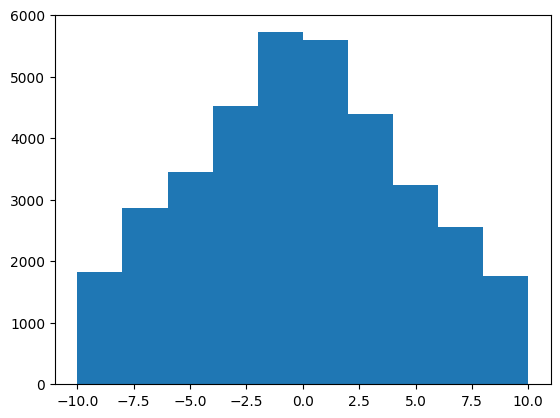

In [ ]:
plt.hist(overlay_df["merge_time"], range=(-10,10))